# 00 · Campaign overview

Integrity, configuration, and headline results of the final campaign `dce-full-rffs-4backbones-xgb-analyses-v2`: RFFS for the four backbones, explainability and uncertainty quantification for XGBoost.  
Everything here is read from recorded artifacts, nothing is re-simulated.

### Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from _shared import (
    BACKBONES,
    BACKBONE_LABELS,
    N,
    OPERATOR_LABELS,
    ROOT,
    SINGLE_COL,
    init_notebook,
    jload,
    run_dir,
)

FIG_DIR, savefig = init_notebook("00_overview")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/00_overview


## Configuration: the paper contract

In [2]:
paper_cfg = yaml.safe_load((ROOT / "configs/default.yaml").read_text())
campaign_cfg = jload(run_dir("xgboost", "rffs") / "manifest.json")["config"]

xgb_delta = pd.DataFrame(
    {
        "paper contract": paper_cfg["models"]["xgboost"],
        "this campaign": campaign_cfg["models"]["xgboost"],
    }
)
xgb_delta["differs"] = xgb_delta["paper contract"] != xgb_delta["this campaign"]
xgb_delta

,paper contract,this campaign,differs
n_estimators,172.000,172.000,False
max_depth,9.000,9.000,False
learning_rate,0.076,0.076,False
colsample_bytree,0.740,0.740,False
subsample,0.600,0.600,False


## Headline: RFFS outcome per backbone

In [3]:
rows = []
for backbone in BACKBONES:
    summary = jload(run_dir(backbone, "rffs") / "rffs_summary.json")
    winner = summary["winner"]
    rows.append(
        {
            "backbone": BACKBONE_LABELS[backbone],
            f"winner {N['psi']}": OPERATOR_LABELS[winner["operator"]],
            N["K"]: winner["K"],
            N["d_plus"]: summary["d_plus"],
            "d_pars": summary["d_parsimonious"],
            "probe floor": round(summary["probe_floor"], 4),
            f"test $R^2$ ({N['d_plus']})": round(
                summary["test_metrics"][f"rffs_d_plus_{summary['d_plus']}"]["r2"], 4
            ),
            f"test MSE ({N['d_plus']})": round(
                summary["test_metrics"][f"rffs_d_plus_{summary['d_plus']}"]["mse"], 4
            ),
        }
    )
headline = pd.DataFrame(rows).set_index("backbone")
headline

,winner $\Psi$,$K$,$d_+$,d_pars,probe floor,test $R^2$ ($d_+$),test MSE ($d_+$)
backbone,,,,,,,
XGBoost,RFE,110,20,18,0.0078,0.7729,0.2330
Random forest,Model importance,30,21,21,0.0033,0.7642,0.2419
LightGBM,RFE,110,19,16,0.0015,0.7642,0.2419
MLP,LASSO,130,57,57,0.0121,0.7649,0.2412


## Test MSE per backbone and feature set (four-model comparison)

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/00_overview/test_mse_by_backbone_and_set.pdf/.png


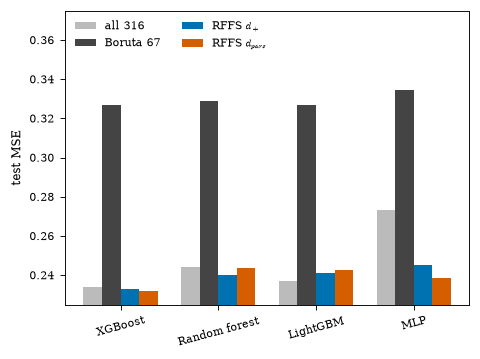

In [4]:
comparison = pd.read_csv(run_dir("xgboost", "comparison") / "model_comparison.csv")
required_columns = {"feature_set", "backbone", "split", "mse"}
missing_columns = required_columns - set(comparison.columns)
if missing_columns:
    raise ValueError(f"comparison artifact is missing columns: {sorted(missing_columns)}")
set_order = ["all_features", "boruta_confirmed", "rffs_summary_d_plus", "rffs_summary_d_parsimonious"]
test_rows = comparison.loc[
    (comparison["split"] == "test") & comparison["feature_set"].isin(set_order)
].copy()
set_labels = {
    "all_features": "all 316",
    "boruta_confirmed": "Boruta 67",
    "rffs_summary_d_plus": f"RFFS {N['d_plus']}",
    "rffs_summary_d_parsimonious": r"RFFS $d_{pars}$",
}
expected_pairs = {(feature_set, backbone) for feature_set in set_order for backbone in BACKBONES}
observed_pairs = set(zip(test_rows["feature_set"], test_rows["backbone"], strict=True))
if len(test_rows) != len(expected_pairs) or observed_pairs != expected_pairs:
    raise ValueError("comparison artifact must contain exactly one test row per feature-set/backbone pair")
if not np.isfinite(test_rows["mse"]).all() or (test_rows["mse"] < 0).any():
    raise ValueError("test MSE values must be finite and non-negative")
test_mse = test_rows.pivot(index="feature_set", columns="backbone", values="mse").loc[set_order, BACKBONES]

fig, ax = plt.subplots(figsize=(4.25, 3.15))
width = 0.19
x = np.arange(len(BACKBONES))
for i, feature_set in enumerate(set_order):
    ax.bar(
        x + (i - 1.5) * width,
        test_mse.loc[feature_set],
        width,
        label=set_labels[feature_set],
        color=["#BBBBBB", "#444444", "#0072B2", "#D55E00"][i],
    )
ax.set_xticks(x, [BACKBONE_LABELS[b] for b in BACKBONES], rotation=15)
ax.set_ylabel("test MSE")
ax.set_ylim(0.225, 0.375)
ax.legend(loc="upper left", ncol=2, frameon=False)
savefig(fig, "test_mse_by_backbone_and_set")
plt.show()

## No-PRS sensitivity campaign  

**Provenance.**  
The fixed-$\tau$ reference is read from `dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/*_rffs_xgboost/rffs_summary.json`.  
The sensitivity result is read from `dce-noprs-xgb-analyses-v1-2026-08-12/xgboost/*_rffs_noprs_xgboost/rffs_summary.json`.  
Category attribution is compared using each campaign's `*_explain_xgboost/category_summary.csv`, which was computed from full-dataset SHAP values for the frozen $d_+$ model.  
The performance comparison uses the recorded XGBoost test split and the recorded $d_+$ feature lists.  
No model is refitted in this notebook.

In [5]:
def summarize_prs_sensitivity(reference: dict, no_prs: dict) -> pd.DataFrame:
    required = {
        "winner",
        "d_plus",
        "d_parsimonious",
        "final_features",
        "test_metrics",
    }
    for label, summary in (("reference", reference), ("no-PRS", no_prs)):
        missing = required.difference(summary)
        if missing:
            raise KeyError(f"{label} summary lacks required fields: {sorted(missing)}")

    excluded = set(no_prs.get("excluded_features", []))
    if no_prs.get("excluded_categories") != ["PRS"]:
        raise ValueError("no-PRS campaign does not record PRS as its sole excluded category")
    if len(excluded) != 154:
        raise ValueError(f"expected 154 excluded PRS features, found {len(excluded)}")

    reference_features = set(reference["final_features"])
    no_prs_features = set(no_prs["final_features"])
    if len(reference_features) != reference["d_plus"]:
        raise ValueError("reference d_plus does not match its recorded feature list")
    if len(no_prs_features) != no_prs["d_plus"]:
        raise ValueError("no-PRS d_plus does not match its recorded feature list")
    if no_prs_features.intersection(excluded):
        raise ValueError("the no-PRS final set contains an excluded feature")

    rows = []
    for label, summary in (("fixed tau, all categories", reference), ("fixed tau, PRS excluded", no_prs)):
        d_plus = summary["d_plus"]
        d_pars = summary["d_parsimonious"]
        winner = summary["winner"]
        rows.append(
            {
                "campaign": label,
                "excluded features": len(summary.get("excluded_features", [])),
                "winner": f"{OPERATOR_LABELS[winner['operator']]}, K={winner['K']}",
                "d_plus": d_plus,
                "d_pars": d_pars,
                "test R2 (FFS)": summary["test_metrics"][
                    f"ffs_{winner['operator']}_K{winner['K']}"
                ]["r2"],
                "test R2 (d_plus)": summary["test_metrics"][
                    f"rffs_d_plus_{d_plus}"
                ]["r2"],
                "test R2 (d_pars)": summary["test_metrics"][
                    f"rffs_d_parsimonious_{d_pars}"
                ]["r2"],
            }
        )

    table = pd.DataFrame(rows).set_index("campaign")
    table["reference d_plus retained"] = [
        len(reference_features),
        len(reference_features.intersection(no_prs_features)),
    ]
    return table


def validate_category_shares(
    categories: pd.DataFrame, expected_d_plus: int, label: str
) -> pd.DataFrame:
    required_columns = {"n_selected", "share_abs_shap"}
    missing = required_columns.difference(categories.columns)
    if missing:
        raise KeyError(f"{label} category summary lacks fields: {sorted(missing)}")
    expected_categories = {"CTX", "PV", "RMC", "WC", "PRS"}
    if set(categories.index) != expected_categories:
        raise ValueError(f"unexpected {label} category index: {sorted(categories.index)}")
    if int(categories["n_selected"].sum()) != expected_d_plus:
        raise ValueError(f"{label} category counts do not sum to its recorded d_plus")
    if not np.isclose(categories["share_abs_shap"].sum(), 1.0):
        raise ValueError(f"{label} absolute SHAP shares do not sum to one")

    table = categories[["n_selected", "share_abs_shap"]].copy()
    table["share_abs_shap_percent"] = 100 * table.pop("share_abs_shap")
    return table


def compare_category_shares(
    reference: pd.DataFrame, no_prs: pd.DataFrame
) -> pd.DataFrame:
    if no_prs.loc["PRS", "n_selected"] != 0:
        raise ValueError("the no-PRS explainability summary retains a PRS feature")
    rows = []
    for category in ("CTX", "PV", "RMC", "WC", "PRS"):
        rows.append(
            {
                "category": category,
                "reference count": reference.loc[category, "n_selected"],
                "reference SHAP share (%)": reference.loc[
                    category, "share_abs_shap_percent"
                ],
                "no-PRS count": no_prs.loc[category, "n_selected"],
                "no-PRS SHAP share (%)": no_prs.loc[
                    category, "share_abs_shap_percent"
                ],
            }
        )
    return pd.DataFrame(rows).set_index("category")


In [6]:
NO_PRS_CAMPAIGN_DIR = (
    ROOT
    / "results/final-campaigns"
    / "dce-noprs-xgb-analyses-v1-2026-08-12"
)
no_prs_runs = sorted((NO_PRS_CAMPAIGN_DIR / "xgboost").glob("*_rffs_noprs_xgboost"))
no_prs_explain_runs = sorted(
    (NO_PRS_CAMPAIGN_DIR / "xgboost").glob("*_explain_xgboost")
)
if len(no_prs_runs) != 1 or len(no_prs_explain_runs) != 1:
    raise FileNotFoundError(
        "expected one no-PRS RFFS run and one explainability run in "
        f"{NO_PRS_CAMPAIGN_DIR}, found {len(no_prs_runs)} and {len(no_prs_explain_runs)}"
    )
reference_path = run_dir("xgboost", "rffs") / "rffs_summary.json"
no_prs_path = no_prs_runs[0] / "rffs_summary.json"
reference_category_path = run_dir("xgboost", "explain") / "category_summary.csv"
no_prs_category_path = no_prs_explain_runs[0] / "category_summary.csv"
required_paths = (
    reference_path,
    no_prs_path,
    reference_category_path,
    no_prs_category_path,
)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"required recorded artifacts are missing: {missing_paths}")

print(f"reference source: {reference_path}")
print(f"no-PRS source:   {no_prs_path}")
print(f"reference category source: {reference_category_path}")
print(f"no-PRS category source:   {no_prs_category_path}")
reference_summary = jload(reference_path)
no_prs_summary = jload(no_prs_path)
prs_sensitivity = summarize_prs_sensitivity(reference_summary, no_prs_summary)
reference_categories = validate_category_shares(
    pd.read_csv(reference_category_path, index_col=0),
    reference_summary["d_plus"],
    "reference",
)
no_prs_categories = validate_category_shares(
    pd.read_csv(no_prs_category_path, index_col=0),
    no_prs_summary["d_plus"],
    "no-PRS",
)
category_sensitivity = compare_category_shares(reference_categories, no_prs_categories)
display(prs_sensitivity.round(4))
category_sensitivity.round(2)


reference source: /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/2026-08-11_18-22-44_rffs_xgboost/rffs_summary.json
no-PRS source:   /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-noprs-xgb-analyses-v1-2026-08-12/xgboost/2026-08-12_14-51-34_rffs_noprs_xgboost/rffs_summary.json
reference category source: /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/2026-08-11_18-29-34_explain_xgboost/category_summary.csv
no-PRS category source:   /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-noprs-xgb-analyses-v1-2026-08-12/xgboost/2026-08-12_14-52-41_explain_xgboost/category_summary.csv


,excluded features,winner,d_plus,d_pars,test R2 (FFS),test R2 (d_plus),test R2 (d_pars),reference d_plus retained
campaign,,,,,,,,
"fixed tau, all categories",0,"RFE, K=110",20,18,0.7844,0.7729,0.7741,20
"fixed tau, PRS excluded",154,"RFE, K=110",22,21,0.7805,0.7739,0.7759,13


,reference count,reference SHAP share (%),no-PRS count,no-PRS SHAP share (%)
category,,,,
CTX,2,7.25,2,7.70
PV,5,17.01,9,49.79
RMC,9,36.24,7,30.63
WC,1,3.47,4,11.88
PRS,3,36.02,0,0.00
